# Ground-based Image Deconvolution with Swin Transformer UNet (SUNet)

### Import Packages

In [1]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

from deconv_sunet import deconv_sunet, tikhonov_filter, instantiate_and_load_sunet

### Load Ground-based Image (VLT) to be deconvolved

Dimensions = (1, 1, 32, 32)


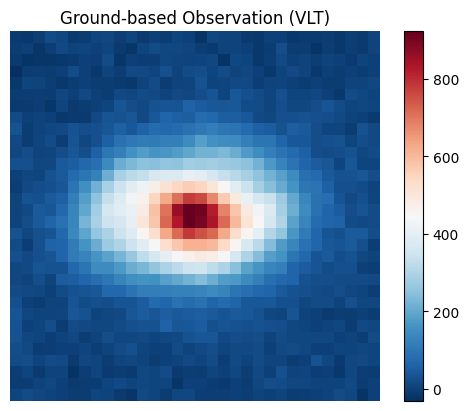

In [2]:
"""    
Convention :

    Input Ground-based noisy Image(s)   : 4D numpy array  (number of samples, channels, height, width).
        
"""

vlt = np.load('Data/vlt.npy')

print('Dimensions =', vlt.shape)
cmap = 'RdBu_r'

plt.imshow(vlt[0,0,:,:], cmap=cmap)
plt.colorbar()
plt.title('Ground-based Observation (VLT)')
plt.axis('off')
plt.show()

### Load the PSF

Dimensions = (1, 128, 128)
PSF Flux = 0.9999684574263173


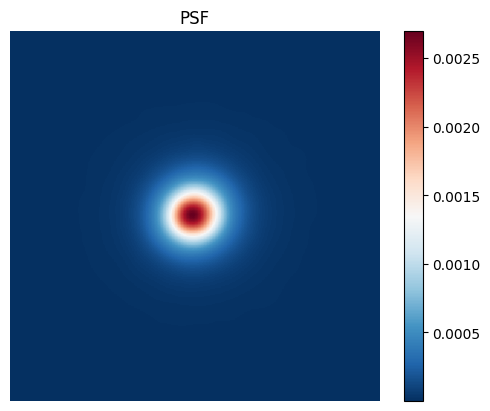

In [3]:
"""    
Convention :

    Point Spread Function (PSF)   : 3D numpy array  (channels, height, width).
    PSF should be flux normalised to 1.
        
"""

psf = np.load('Data/psf_vlt.npy')
psf = np.expand_dims(psf, axis=0)

print('Dimensions =', psf.shape)
print('PSF Flux =', np.sum(psf))          # PSF should be flux normalised to 1

plt.imshow(psf[0,:,:], cmap=cmap)
plt.colorbar()
plt.title('PSF')
plt.axis('off')
plt.show()

### Load the Space-based Image (HST) for comparison

Dimensions = (128, 128)


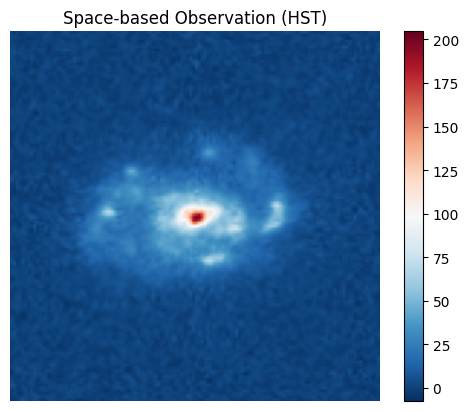

In [4]:
hst = np.load('Data/hst.npy')

print('Dimensions =', hst.shape)

plt.imshow(hst, cmap=cmap)
plt.colorbar()
plt.title('Space-based Observation (HST)')
plt.axis('off')
plt.show()

### Run Deconvolution

In [8]:
"""
    Run the SUNet deconvolution
    Replace the input paths with the path to your cloned SUNet repository and the path to your SUNet model directory.
"""

# Factor by which the PSF is oversampled with respect to the noisy image
# Deconvolved ouput will have the same dimensions as the PSF    

# Run the SUNet deconvolution
# the balance value is determined using a line search
balance = 9e-3
tikho_deconv = tikhonov_filter(vlt, psf, balance)
model_dir = '/data/fnammour/sunet/'
model_name = 'SUNet_bestSSIM_ep-400_bs-16_ps-1.pth'
model_path = Path(model_dir) / model_name

model = instantiate_and_load_sunet(checkpoint_path=model_path, device=torch.device("cpu"))

deconv_result = deconv_sunet(tikho_deconv,
                            model)

deconv_result.shape

(1, 1, 128, 128)

### Plot Results

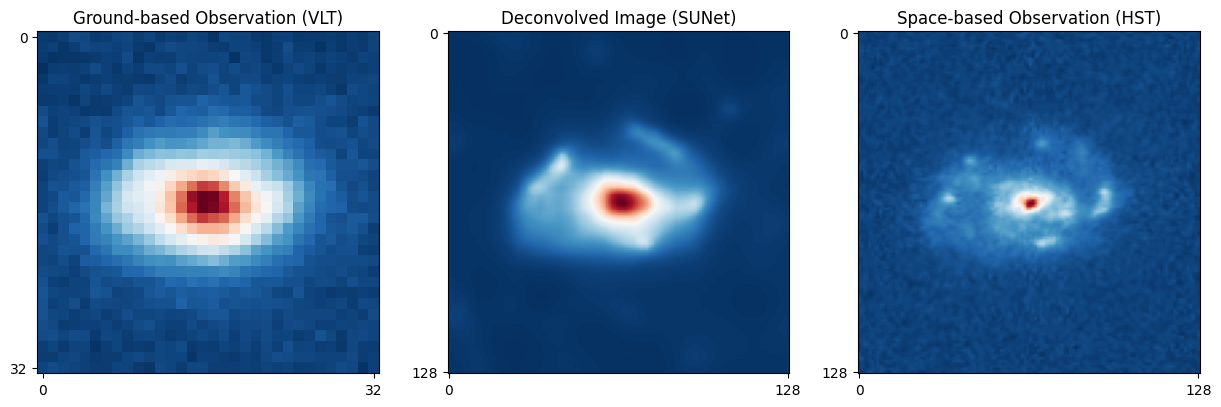

In [9]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
im1 = ax[0].imshow(vlt[0,0], cmap=cmap)
ax[0].set_title('Ground-based Observation (VLT)')
ax[0].set_xticks([0, vlt[0,0].shape[0]-1], labels=[0, vlt[0,0].shape[0]])
ax[0].set_yticks([0, vlt[0,0].shape[1]-1], labels=[0, vlt[0,0].shape[1]])

im2 = ax[1].imshow(deconv_result[0,0], cmap=cmap)
ax[1].set_title('Deconvolved Image (SUNet)')
ax[1].set_xticks([0, deconv_result[0,0].shape[0]-1], labels=[0, deconv_result[0,0].shape[0]])
ax[1].set_yticks([0, deconv_result[0,0].shape[1]-1], labels=[0, deconv_result[0,0].shape[1]])

im3 = ax[2].imshow(hst, cmap=cmap)
ax[2].set_title('Space-based Observation (HST)')
ax[2].set_xticks([0, hst.shape[0]-1], labels=[0, hst.shape[0]])
ax[2].set_yticks([0, hst.shape[1]-1], labels=[0, hst.shape[1]])

plt.show()